# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Kristyne | Hawkshaw | Kristyne Hawkshaw, Nov 19, 2025 | 9 | 25% |
| Member 2: | Rachel | Peszneker | Signature | Hours | 25% |
| Member 3: | Eric | Fagan | Signature | Hours | 25% |
| Member 4: | Joey | Craig | Joey Craig, Nov 27, 2025| 10 | 25% |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

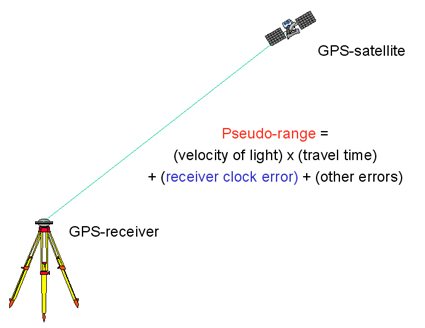

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
file_path = '/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part1_data'
df_pseudorange = pd.read_excel(f'{file_path}/pseudoranges.xlsx')
df_sat_pos = pd.read_excel(f'{file_path}/satellite_position.xlsx')


pseudorange = df_pseudorange.to_numpy()
pseudorange=pseudorange[:,1]
#converting the psuedorange data into NumPy array
sat_pos = df_sat_pos.to_numpy()
sat_pos=sat_pos[:,1:4]
#converts the satellite position data to Numpy array

np.random.seed(42)  # For reproducible results
#makes sure the same noise is cresated for each time the program is rancreated for each time the program is ran
pseudorange = pseudorange + np.random.uniform(-0.5, 0.5, pseudorange.shape)
#random numbers are within the same range as the pseudorange data


In [ ]:
# define the number of measurements n and the number of unknown states m
# (2 mark)
n = 11
# this is the number of satellites that are positioned and are observed
m = 4
# the unknowns are the 3 postions of GPS coordinates (x,y,z) and the clock set

In [ ]:
# GroundTruth coordiantes of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [ ]:
# define a function called euclidean_norm, which computes the geometric distances between satellites and receiver
# the input of the function should be two arrays: receiver_pos and satellite_pos
# the function should return an array of distance between satellites and receiver
# you can either use the numpy function or code the math manually
# (2 marks)
def euclidean_norm(receiver_pos, satellite_pos):

    receiver_pos = np.array(receiver_pos)
    satellite_pos = np.array(satellite_pos)
    # Makes sure that the inputs are numpy arrays

    diff_vectors = satellite_pos - receiver_pos
    # Calculates the difference vector between the satellites and the receiver

    distance_squared = np.sum(diff_vectors**2, axis=1)
    # Calculates the squared Euclidean norm for each satellite

    distance = np.sqrt(distance_squared)
    # To get the final distance, calculate the square


    return distance


## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [ ]:
varience = 1.2
P = np.identity(n) * (1/varience**2)
print(P)

[[0.69444444 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.69444444 0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.69444444 0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.69444444 0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.69444444 0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.69444444
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.69444444 0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.69444444 0.         0.         0.        ]
 [0.         0.         0.         0.         0.

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [ ]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [ ]:
delta = 10
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = x_0.copy()

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [ ]:
def design_matrix(receiver_pos, satellite_pos, distance):
    N = satellite_pos.shape[0]
    A = np.zeros((N, 4))

    # Retrive the estimated receiver coordinates
    r_x, r_y, r_z = receiver_pos[:3]

    for i in range(N):
        s_x, s_y, s_z = satellite_pos[i]

        # Calculate the distance to the estimated position
        delta_x = -s_x + r_x
        delta_y = -s_y + r_y
        delta_z = -s_z + r_z
        calc_dist = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

        # Calculate the line-of-sight unit vectors (partial derivatives)
        A[i, 0] = delta_x / calc_dist
        A[i, 1] = delta_y / calc_dist
        A[i, 2] = delta_z / calc_dist

        # The constant term
        A[i, 3] = -1


    return A


### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [ ]:

print(GroundTruth)
distance = euclidean_norm(x_hat[:3], sat_pos)
print(distance)


[-1633489.37967725 -3651627.18250363  4952481.61954918]
[26454211.72800791 26340898.41004467 26277663.88799113 26596023.29879138
 26695784.20342012 26747545.60979348 26616654.66386916 26595146.0858906
 26353644.12759512 26939970.90681485 26982792.5803867 ]


In [ ]:
while (np.linalg.norm(delta) > 0.008):
  # compute the geometric distance between Satellites and receiver, using the euclidean_norm function we just defined
  # (0.5 marks)

  distance = euclidean_norm(x_hat[:3], sat_pos)

  # compute the design matrix A
  # (0.5 marks)
  A = design_matrix(x_hat[:3], sat_pos, distance)

  # compute the misclosure array w
  # (0.5 marks)
  w = pseudorange - (distance - x_hat[3])
  print(A)
  print(w)

  # compute the corrections delta
  # (0.5 marks)
  delta = np.linalg.inv(A.T @ P @ A) @ A.T @ P @ w # Corrected for weighted least squares

  # update the states
  x_hat = x_hat + delta

  print(x_hat[:3])
  print(GroundTruth)

  # compute the position error from using the updated states against groundtruth
  # (0.5 marks)
  err_pos = x_hat[:3] - GroundTruth

  # update the counter i, (i.e., increament of 1 for each iteration)
  i += 1

  # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
  # (0.5 marks)
  arr_w.append(w)
  arr_delta.append(delta)
  arr_err_pos.append(err_pos)
  arr_i.append(i)




# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
v = w # 'w' from the final iteration is the residual vector
m_obs = n # n is defined as the number of measurements
n_states = m # m is defined as the number of unknown states
apv = (v.T @ P @ v) / (m_obs - n_states) # Corrected for weighted least squares

# compute the Covariance matrix of estimated states
# (0.5 marks)'
C_x_hat = apv * np.linalg.inv(A.T @ P @ A) # Corrected for weighted least squares

[[-0.1996163   0.96398299 -0.17575588 -1.        ]
 [ 0.0819925   0.80164216 -0.5921546  -1.        ]
 [-0.39469841  0.82629344 -0.40181129 -1.        ]
 [ 0.60482203 -0.16111887 -0.77989167 -1.        ]
 [ 0.53615537  0.82578448 -0.17497832 -1.        ]
 [ 0.09106698 -0.60780362 -0.78884825 -1.        ]
 [-0.59783498  0.13008642 -0.79099359 -1.        ]
 [-0.6118315   0.00822392 -0.79094537 -1.        ]
 [ 0.73034057  0.27547438 -0.62507321 -1.        ]
 [ 0.59136114 -0.44830847 -0.67030703 -1.        ]
 [ 0.28463007  0.51349069 -0.80951407 -1.        ]]
[-3533470.89203829 -5880003.87153157 -3876325.24258378 -3765882.2875325
 -4352769.73022618 -1100091.41750576 -2800878.86036275 -2282746.40256235
 -4999003.88580081 -1967361.06130758 -6342812.0008017 ]
[-1922872.29999392 -4255886.20956824  5906172.44802931]
[-1633489.37967725 -3651627.18250363  4952481.61954918]
[[-0.32060761  0.94555945  0.05592933 -1.        ]
 [ 0.01217482  0.86690521 -0.49832432 -1.        ]
 [-0.56260611  0.798841

### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [ ]:

print("Estimated States:", x_hat)
print("Corrections:", delta)
print("Estimated Measurements Residuals:", w)
print("A posteriori Variance of Unit Weight:", apv)
print("Covariance matrix of estimated states:", C_x_hat)
print("Number of iterations:", i)
print("3-D position errors:", err_pos)


Estimated States: [-1.63349247e+06 -3.65162952e+06  4.95248541e+06 -6.43294565e+00]
Corrections: [ 3.25067013e-06  6.46546692e-06 -1.78568459e-05  2.10595604e-05]
Estimated Measurements Residuals: [ 0.14970377  0.57364262 -0.86136429  0.13700595 -0.10613019 -1.72343421
 -0.52714028  1.88707428  0.40683754  0.87050822 -0.8068244 ]
A posteriori Variance of Unit Weight: 0.8252498614195907
Covariance matrix of estimated states: [[ 0.37985929  0.08278406 -0.10050198  0.08683204]
 [ 0.08278406  0.50560994 -0.69052199  0.43762372]
 [-0.10050198 -0.69052199  2.4309107  -1.31197379]
 [ 0.08683204  0.43762372 -1.31197379  0.83096935]]
Number of iterations: 5
3-D position errors: [-3.08785868 -2.34179516  3.78920208]


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [ ]:
# A Posteriori Variance of Unit weight is an indicator of the overall quality of a least squares adjustment. Being close to 1.0 indicates that the estimates of the observation variances were realistic and consistent with the actual errors. This means that this is an optimal model.
#The covariance matrix of estimated states show informtation on the precision, reliabilty, and the relationships.
  #The diagonal indicates the spread of the estimated values around the average. Higher numbers show more uncertainty.
  #The other number show covariances. Positive numbers show estimate is larger than its average whil negative is below.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

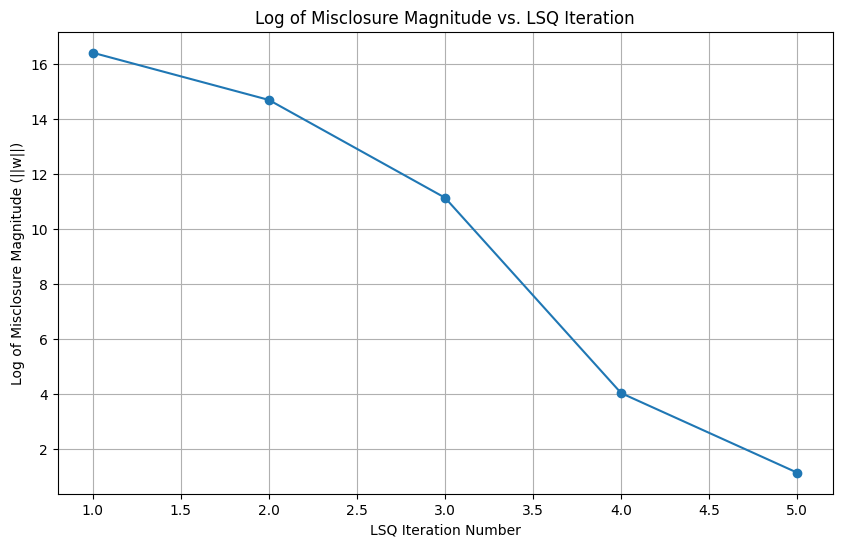

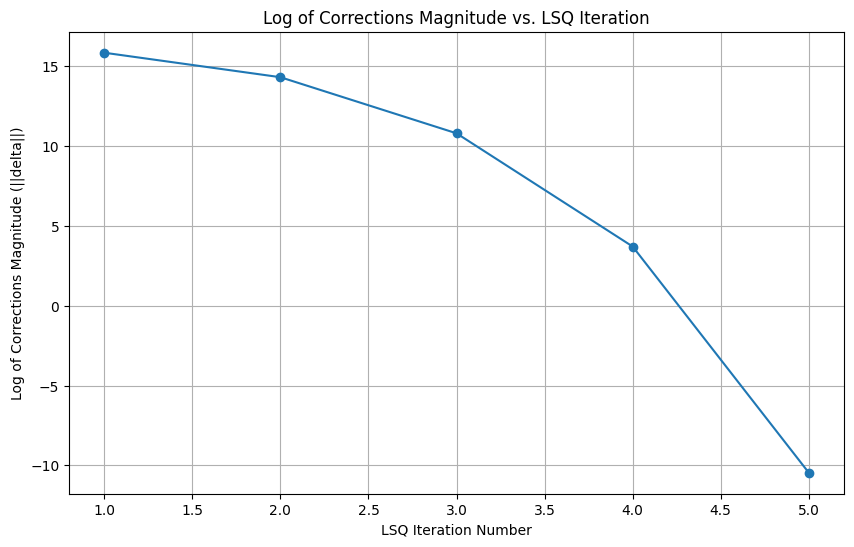

/tmp/ipython-input-310171697.py:38: RuntimeWarning: invalid value encountered in log
  log_err_pos = np.log(arr_err_pos)


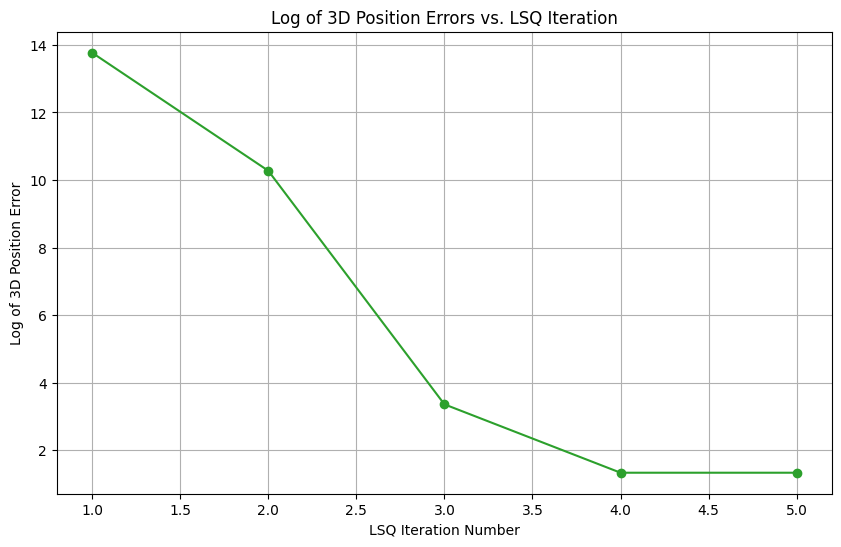

In [ ]:
# 1. Plot log of the misclosure w against the LSQ iteration number i
# (1 marks)

#pulling the target inforamtion and using the natural logarithm
misclosure_magnitudes = [np.linalg.norm(w_vec) for w_vec in arr_w]
log_misclosure = np.log(misclosure_magnitudes)

# Creating the size and labels og the graph
plt.figure(figsize=(10, 6))
plt.plot(arr_i, log_misclosure, marker='o', linestyle='-')
plt.xlabel('LSQ Iteration Number')
plt.ylabel('Log of Misclosure Magnitude (||w||)')
plt.title('Log of Misclosure Magnitude vs. LSQ Iteration')
plt.grid(True)
plt.show()

# 2. Plot log of the corrections delta against the LSQ iteration number i
# (1 marks)

# Pulling target information and using log scale
delta_magnitudes = [np.linalg.norm(d_vec) for d_vec in arr_delta]
log_delta = np.log(delta_magnitudes)

# Creating the size and labels of plot
plt.figure(figsize=(10, 6))
plt.plot(arr_i, log_delta, marker='o', linestyle='-')
plt.xlabel('LSQ Iteration Number')
plt.ylabel('Log of Corrections Magnitude (||delta||)')
plt.title('Log of Corrections Magnitude vs. LSQ Iteration')
plt.grid(True)
plt.show()


# 3. Plot log of the 3D position errors against the LSQ iteration number i
# (1 marks)

# Pulling target information and using log scale
log_err_pos = np.log(arr_err_pos)

# Creating the size and labels of plot
plt.figure(figsize=(10, 6))
plt.plot(arr_i, log_err_pos, marker='o', linestyle='-')
plt.xlabel('LSQ Iteration Number')
plt.ylabel('Log of 3D Position Error')
plt.title('Log of 3D Position Errors vs. LSQ Iteration')
plt.grid(True)
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [ ]:
# The log of the misclosure against the LSQ shows if the model is converging correctly. This plot is trending downwards which show the algorithm is converging.
# The log of the corrections delta against the LSQ also show convergence. The downward curve above represents that it is converging.
# The log of the 3D position errors against the LSQ show the quality of the calculations. the decreasing line shows the error is lessening.

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [ ]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [ ]:
# Cost function: sum of squared residuals between measured and predicted pseudoranges
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
  residuals = []
  for i, sat_p in enumerate(sat_pos):
    # Calculate geometric predicted range
    calc_distance = np.linalg.norm(rec_pos - sat_p)
    # Predicted pseudorange with geometric distance and receiver clock bias
    pseudorange_predicted = calc_distance + cdT
    # Calculate the residual for the satellite
    residual = pseudorange[i] - pseudorange_predicted
    residuals.append(residual)

  # Calculate the sum of squared residuals
  L = np.sum(np.array(residuals)**2)

  return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [ ]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange_measured):
    # Calculate distances
    geometric_distances = euclidean_norm(rec_pos, sat_pos)

    # Calculate predicted pseudoranges
    pseudorange_predicted = geometric_distances - cdT

    # Calculate residuals
    residuals = pseudorange - pseudorange_predicted

    # The design_matrix function is defined to return A
    A = design_matrix(rec_pos, sat_pos, geometric_distances)
    # Gradient of the sum of squared residuals is -2 * A.T @ residuals
    grad = -2 * A.T @ residuals

    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [ ]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):

    global steps_count

    #initalize the estimates as zeros
    X = np.array([50.0, -25.0, 15.0, 500.0])

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT = X[3]

        # compute the cost in the current step
        # (1 mark)
        current_cost = cost_function(rec_pos, cdT, sat_pos, pseudorange)

        # compute the gradients in the current step
        # (1 mark)
        grad = gradient(rec_pos, cdT, sat_pos, pseudorange)


        # update estimates
        # (1 mark)
        X_new = X - learning_rate * grad

        # compute the new cost
        # (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], sat_pos, pseudorange)

        # break the loop if converge
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged !")
            steps_count=iteration
            break

        # update the parameters for the next iteration
        X = X_new

        #collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3]-GroundTruth)

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [ ]:
optimized_params = gradient_descent(pseudorange, sat_pos)

# print the mentioned metrics
# (0.5 marks)
print("Optimized Parameters:", optimized_params)
print("Final Position Errors:", optimized_params[:3] - GroundTruth)
print("Number of Steps:", steps_count)
print("Final Cost:", arr_cost[-1])
print("Final Gradient:", arr_grad[-1])

Optimized Parameters: [-1616184.60978368 -4389634.81437011  8306848.13053133 -6327555.97164885]
Final Position Errors: [  17304.76989357 -738007.63186648 3354366.51098214]
Number of Steps: 0
Final Cost: 30988629317209.42
Final Gradient: [-7.33346439e+06 -2.01747336e+07  3.40946835e+07  1.04702035e+08]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

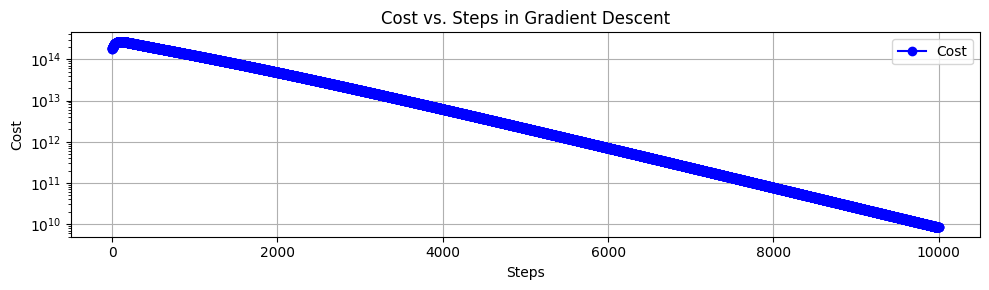

In [ ]:
fig , ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# (0.5 marks)

# Plotting cost vs steps
ax.semilogy(range(len(arr_cost)), arr_cost, marker='o', linestyle='-', color='blue', label='Cost')
ax.set_xlabel('Steps')
ax.set_ylabel('Cost')
ax.set_title('Cost vs. Steps in Gradient Descent')
ax.legend()

ax.grid(True)
fig.tight_layout()
plt.show()
# Comment on the pattern (0.5 marks)
# The plot shows that the cost function generally decreases with each step. This indicates that the gradient descent algorithm is converging.

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

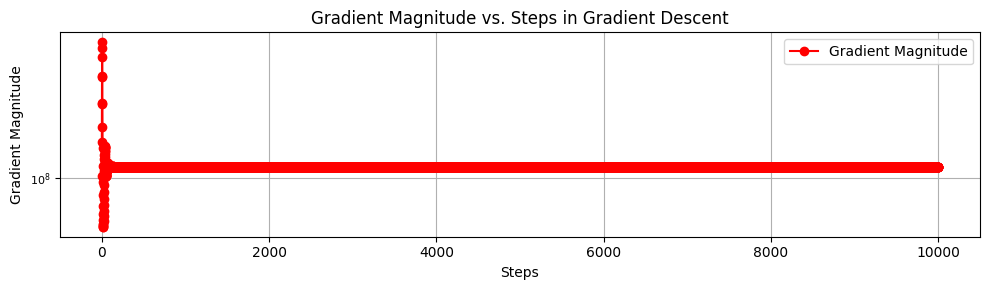

In [ ]:
fig, ax = plt.subplots(nrows=1,ncols=1, figsize=(10,3))
# Calculate the magnitudes of the gradient vectors
gradient_magnitudes = [np.linalg.norm(g) for g in arr_grad]

# Plotting gradients vs steps
ax.plot(range(len(gradient_magnitudes)), gradient_magnitudes, marker='o', linestyle='-', color='red', label='Gradient Magnitude')
ax.set_xlabel('Steps')
ax.set_ylabel('Gradient Magnitude')
ax.set_title('Gradient Magnitude vs. Steps in Gradient Descent')
ax.set_yscale('symlog') # Use symlog scale for y-axis
ax.tick_params(axis='y', labelsize=8) # Set y-axis labelsize
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

# Comment on the pattern (0.5 marks)
# The plot shows that the magnitude of the gradients decreases as the number of steps increases and approaching a local minimum where the gradient approaches zero.


### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

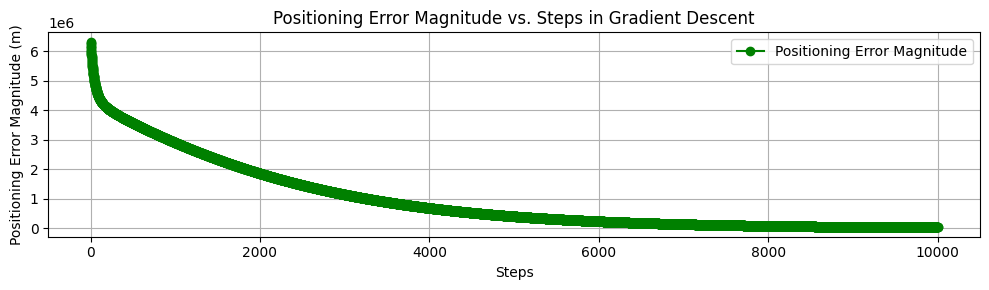

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3))

# Calculate the magnitudes of the 3D position errors
position_error_magnitudes = [np.linalg.norm(err) for err in arr_err]

# Plotting positioning errors vs steps
ax.plot(range(len(position_error_magnitudes)), position_error_magnitudes, marker='o', linestyle='-', color='green', label='Positioning Error Magnitude')
ax.set_xlabel('Steps')
ax.set_ylabel('Positioning Error Magnitude (m)')
ax.set_title('Positioning Error Magnitude vs. Steps in Gradient Descent')
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

# Comment on the pattern
# The plot shows that the magnitude of the positioning errors decreases as the number of steps increases. This shows that the gradient descent algorithm is refining the receiver's position estimate towards the true ground truth.


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [ ]:
#set learning rate to 0.008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_2 = gradient_descent(pseudorange, sat_pos, learning_rate=0.008)

# print the metrics
print("Optimized Parameters:", optimized_params_2)
print("Final Position Errors:", optimized_params_2[:3] - GroundTruth)
print("Number of Steps:", steps_count)
print("Final Cost:", arr_cost[-1])

Converged !
Optimized Parameters: [-1.63349247e+06 -3.65162952e+06  4.95248541e+06 -6.43294508e+00]
Final Position Errors: [-3.08785862 -2.34179483  3.78920108]
Number of Steps: 5268
Final Cost: 1830.3493087725913


In [ ]:
#set learning rate to 0.0008
#re-initialize arrays and counters
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

# (1 marks)
optimized_params_3 = gradient_descent(pseudorange, sat_pos, learning_rate=0.0008)

# print the metrics
print("Optimized Parameters:", optimized_params_3)
print("Final Position Errors:", optimized_params_3[:3] - GroundTruth)
print("Number of Steps:", steps_count)
print("Final Cost:", arr_cost[-1])

Optimized Parameters: [-1632077.98249297 -3643754.16180929  4928283.79853934    13723.60211787]
Final Position Errors: [  1411.39718428   7873.02069434 -24197.82100984]
Number of Steps: 0
Final Cost: 8325643710.43412


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [ ]:
# With the learning rate of 0.008, the algorithm successfully converged in 5268 steps. The final position errors were small and the final cost was reduced. This means this learning rate was suitable for this problem.

# With the learning rate of 0.0008, it resulted in steps_count=0, a high final cost, and larger position errors. This indicates that this rate was likely too small.


# Non-linear LSE (NLS) linearizes non-linear observations using an initial guess at each iteration. Next, it solves a linear system to find the optimal correction for the unknown states. This process is repeated until convergence.
#This algorithm converged in 5 iterations with precise 3-D position errors (-3.08785868, -2.34179516, 3.78920208). This shows it had a high efficiency and accuracy for this problem.


#Gradient Descent minimizes a cost function by taking small steps in the direction opposite to the gradient of the function. The size of these steps is determined by the learning_rate. It iteratively approaches the minimum by following the path of steepest descent.
#Gradient Descent exhibits linear convergence, and its learning rate determines its speed.
# During this assignment, the optimal learning rate was 0.008, where Gradient Descent converged in 5268 steps. With the suboptimal learning rates of 0.08 and 0.0008, it failed to converge within the given maximum iterations, producing larger errors.

# LSE was a more efficient method than Gradient descent due to its faster convergence and less reliance on hyperparameter tuning.

---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd drive/MyDrive/ENGG680_2025_Fall

/content/drive/MyDrive/ENGG680_2025_Fall


In [ ]:
!ls

'Introduction to Machine Learning'  'Lab_Assignment 1'	 README.md
'Introduction to Python'	     Lab_Assignment2


In [ ]:
%cd Lab_Assignment2/part2_data
!ls

/content/drive/MyDrive/ENGG680_2025_Fall/Lab_Assignment2/part2_data
'Student Depression Dataset.csv'  'Student Depression Dataset.gsheet'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [ ]:
# Load the Student Depression Dataset
data = pd.read_csv('Student Depression Dataset.csv')

# Basic data preprocessing
data = data.drop(columns=['id'])  # Remove irrelevant ID column
data = data.dropna(   )  # Remove rows with missing values
data = data.drop_duplicates(   )  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
columns_with_others = ['City', 'Profession'] #columns that contain'Others'

for col in columns_with_others:
    data = data[data[col] != 'Others'] #remove rows that contain 'others' in their column


# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print(data.shape)
data.head() #displays the first 5 rows

(27898, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
# creates list of categorical data
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

# for loop goes through each column name in the list and creates label encoding
for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])


# Prepare feature matrix X and target vector y (1 marks)
target_variable = 'Depression' # column we want to predict
y =  data[target_variable] # y is the target column
X =  data.drop(columns=[target_variable]) # X is the columns other than the target column

# Display sizes of X and y
# print the number of columns and rows for X and y.
print("Shape of X:", X.shape)
print("Shape of Y:", y.shape)

Shape of X: (27898, 16)
Shape of Y: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

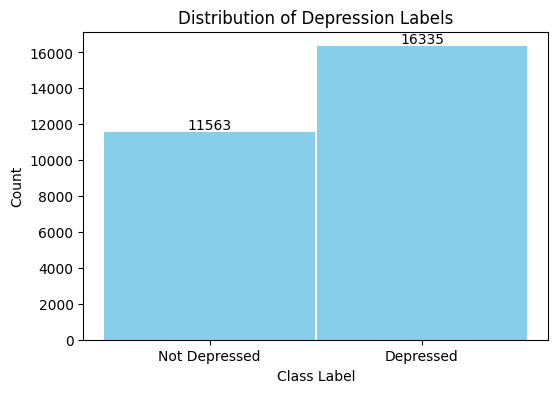

In [ ]:
# Check the class distribution of y
# counts how many samples are labeled 0 to 1 and sorts them by their label
counts = y.value_counts().sort_index()

# create a histogram
plt.figure(figsize=(6,4))
bars = plt.bar(counts.index, counts.values, color='skyblue', width=0.99)

# label the chart axis and title
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Distribution of Depression Labels")
plt.xticks([0, 1], ['Not Depressed', 'Depressed'])

# Display exact values for each bin in the histogram
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom')

# plots the histogram
plt.show()

### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [ ]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
# splits the data into two parts, 0.03 of the data goes into the small data set.
# The remaining 97% goes into the unused variables.
X_unused, X_small,y_unused, y_small = train_test_split(X, y, test_size=0.03, random_state=42)

# Display sizes of X_small and y_small (0.5 marks)
# displays how many rows and columns in the small data set.
print("Size of X_small:", X_small.shape)
print("Size of y_small:", y_small.shape)

Size of X_small: (837, 16)
Size of y_small: (837,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

# creates a logistic regression model
model = LogisticRegression(max_iter=2000)
# creates an empty data frame to store results from each evaluation
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
                               "Training accuracy", "Testing accuracy", "Log loss"])

# defines a function
# splits data into 30% testing and 70% training
def evaluate_model(X_data, y_data, label):

    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=0)

    #Logistic Regression test
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train, y_train)

    #Makes predictions for each model
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)

    #Metrics: counts the number in the input and how many were in the training and testing data
    data_size = len(y_data)
    train_samples = len(y_train)
    test_samples = len(y_test)
    #how accurate the model is and measures the model quality theough the log loss, where lower is better.
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    ll = log_loss(y_test, y_test_prob)

    results.loc[label] = [data_size, train_samples, test_samples,train_acc, test_acc, ll]
    #returns the data
    return X_train, X_test, y_train, y_test

# run each test
# Test 1: Full dataset (X and y)
evaluate_model(X, y, "All features (full data)")

# Test 2: Only first two columns of X and y
X_first2 = X.iloc[:, :2]
evaluate_model(X_first2, y, "First 2 features")

# Test 3: Small dataset (X_small and y_small)
evaluate_model(X_small, y_small, "3% subset")

# Print results
print(results)

                          Data size  Training samples  Testing samples  \
All features (full data)    27898.0           19528.0           8370.0   
First 2 features            27898.0           19528.0           8370.0   
3% subset                     837.0             585.0            252.0   

                          Training accuracy  Testing accuracy  Log loss  
All features (full data)           0.846887          0.846117  0.348357  
First 2 features                   0.631708          0.634170  0.652715  
3% subset                          0.846154          0.829365  0.374545  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [ ]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# creates a logistic regression model and feeds the training data into the model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# uses the model to predict labels for the test data
y_test_pred = model.predict(X_test)

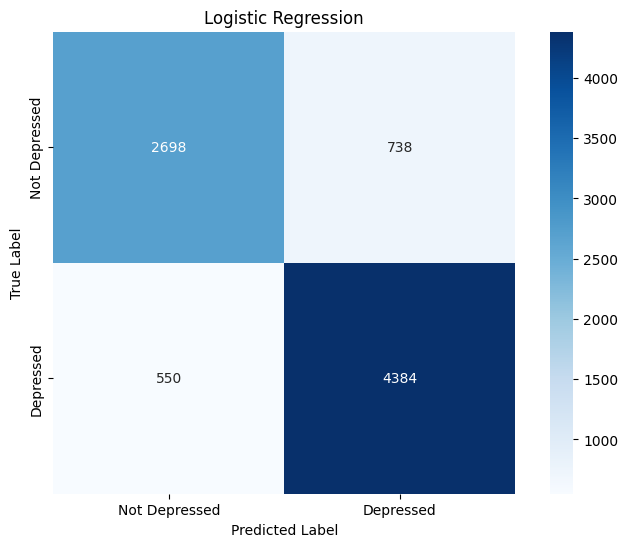

In [ ]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_test, y_test_pred)

# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(9, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
# labels and titles for heatmap
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression")
# show the heatmap
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print(classification_report(y_test, y_test_pred, target_names=['Not Depressed', 'Depressed']))

               precision    recall  f1-score   support

Not Depressed       0.83      0.79      0.81      3436
    Depressed       0.86      0.89      0.87      4934

     accuracy                           0.85      8370
    macro avg       0.84      0.84      0.84      8370
 weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)
# three models being trained with its given name and model object
models = {"Logistic Regression": LogisticRegression(max_iter=2000),
          "Naive Bayes": GaussianNB(),
          "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)}

# Train and evaluate each model using the full dataset (0.5 marks)
# creates an empty dictionary to store values for each model
model_results = {}

for name, model_instance in models.items():
    # Train the model using the training dataset
    model_instance.fit(X_train, y_train)

    # Make predictions of the model for the 3% data set
    y_test_pred = model_instance.predict(X_test)

    # Calculate accuracy, compares the predicted labels to the real labels
    acc = accuracy_score(y_test, y_test_pred)
    model_results[name] = acc

    # Print results of each model and its accuracy.
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.8461
Naive Bayes Accuracy: 0.8364
KNN (k=5) Accuracy: 0.7462


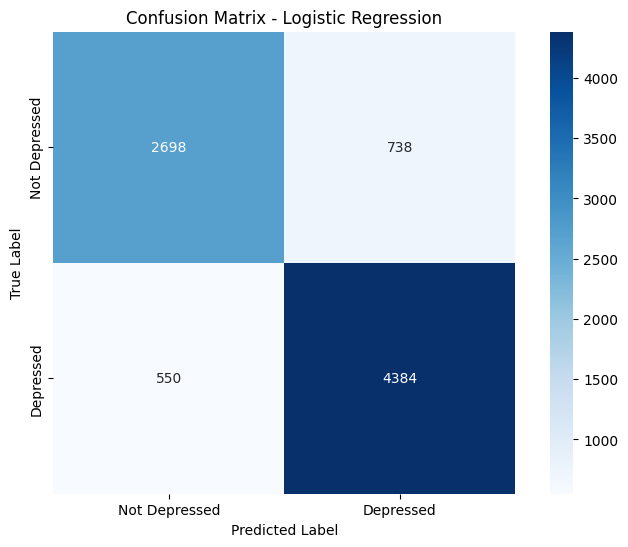

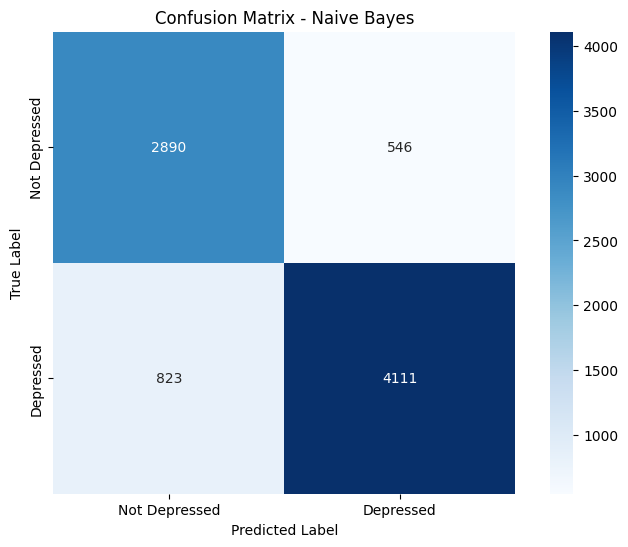

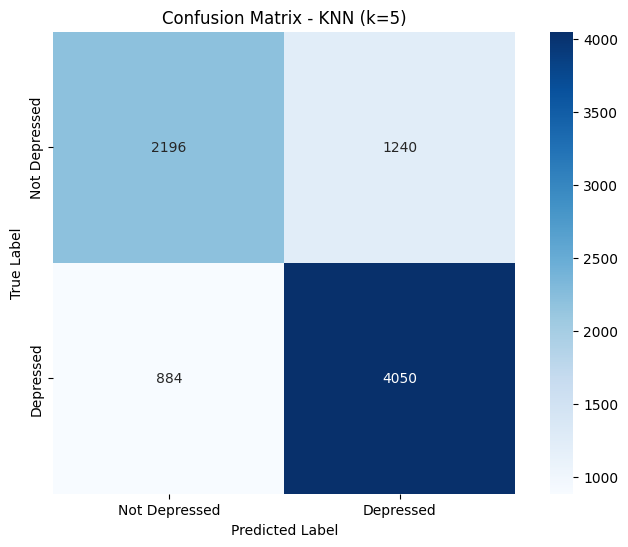

In [ ]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)

for name, model_instance in models.items():
    # Predictions used to build the confusion matrix
    y_test_pred = model_instance.predict(X_test)

    # Confusion matrix compares the true labels with the predicted labels
    conf_mat = confusion_matrix(y_test, y_test_pred)

    # Plots each confusion matrix for logistic regression, Naive Bayes and KNN.
    plt.figure(figsize=(9,6))
    sns.heatmap(conf_mat,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Depressed', 'Depressed'],
        yticklabels=['Not Depressed', 'Depressed'],
        square=True)

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

1. The dataset is very slightly imbalanced and slightly impacts model performance.
2. The model does not over or underfit for the three cases.
3. When given full access to the datasets, the training and testing accuracy remain high and within a very close percentage range of 84.6887% and 84.6117% respectfully (only differing by 0.077% with the training accuracy being slightly higher). When only the first two columns of the data are used for modeling, the overall accuracy for both drop significantly - down to 63.1708% and 63.4170%, a drop of 21.518% and 21.1947% respectively - though they remain similarly accurate with only a 0.2462% difference, albeit still a greater difference than with the full model and with testing now having the higher accuracy. When only using a 3% subset of the data, the drop from the full subset is much lower (to 84.6154 and 82.9365% with a 0.0733% and 1.6752% drop respectively) when compared to the over 20% drops of the 2-column method - but the accuracy difference between testing and training jumps to 1.6789%, far higher than even the 2-column method and keeping the higher training accuracy of the full model.
4. A false positive indicates the student suffering from depression when they don't, a false negative indicates them as healthy when they are dealing with depression - the latter is definitely worse since the false positive can be addressed quickly but the false negative flying under the radar is very problematic and does not allow for the intention behind the design of the model to work out or allow for the student to get help.
5. You would want to maximize recall to minimize false positives, which I would do by lowering the threshold for the regression (makes it more sensitive to positive cases) by defining the new, lowered threshold value then using model.predict_proba() to retrain and test the model with the updated threshold.
6. The model in the first case is moderately good at giving correct classifications given the mid-30% log loss, and has the lowest loss of the group due to including the entirety of the data. The second case has a far higher log loss - slightly over 65% - indicating that it is much worse at correctly classifying the data, which is potentially caused by the model dropping several columns worth of data to train and test the model on. The third case has a similar (albeit slightly higher) log loss than the first case in the mid-high 30% range, thus indicating similarly good but slightly worse classifications - this slight decrease could potentially come from the 3% subset of the used data not having the same amount of points to smooth out trends or having a proportionally larger size of data points that negatively impact classification correctness than what would be present in the full dataset.
7. Out of the three models, the Logistic Regression had the highest accuracy and performed the best overall. It was followed closely by the Naive Bayes model and then the significantly less accurate K-Nearest Neighbor model. This divide of performances was due to the logistic regression model being designed for generalized binary regression & classification with multi-category dependent variables and the assumption that said variables are unnormalized so they can be converted into a raw probability vector - something which matched very well with the format of the data and the intended classification. K-Nearest Neighbor trailed behind because it works best with several clusters to separate data into as opposed to the more binary classification aimed for here and it assumes that the point can be classified based upon the majority of the "nearest neighbor" points (which while there are some trends for depression it also isn't entirely consistent to said trends which could mess with this method), leaving it with comparatively subpar accuracy as a result. Naive Bayes is left in the middle of the classification options (though still a well-performing choice), as while its classification methods assuming conditional independence of the data points and being a probabilistic-based model are helpful here, it does not fit quite as well as the Logarithmic Regression model as the data points' features are not completely independent of each other (unlike its assumption).


---
---

# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path = "mnist_train.csv"
test_csv_path = "mnist_test.csv"

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data = pd.read_csv(train_csv_path)
y_train = train_data.iloc[:, 0].values
X_train = train_data.iloc[:, 1:].values

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train = X_train.reshape(-1, 28, 28)

# Load test data (0.5 marks)
test_data = pd.read_csv(test_csv_path)
y_test = test_data.iloc[:, 0].values
X_test = test_data.iloc[:, 1:].values

# Reshape test data to match training data format (0.5 marks)
X_test = X_test.reshape(-1, 28, 28)

# Display the shapes of training and test sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:",  X_test.shape)
print("y_test shape:",  y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


Let's visualize some sample images to understand what our models will be learning from.

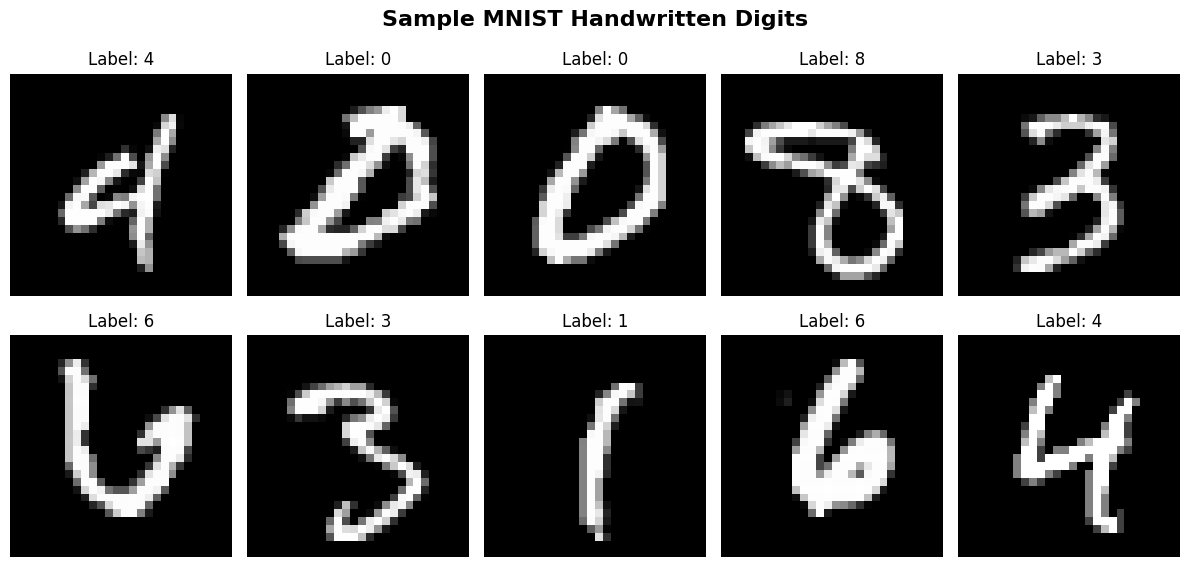

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)
        tf.keras.layers.Flatten(input_shape=(28, 28)),

        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)
        tf.keras.layers.Dense(128, activation='relu'),

        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)
         tf.keras.layers.Dropout(0.2),

        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)
        tf.keras.layers.Dense(64, activation='relu'),

        # Another dropout layer for regularization, same with above
        # (1 marks)
        tf.keras.layers.Dropout(0.2),

        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)
         tf.keras.layers.Dense(10, activation='softmax')

    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

MLP Model created


**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS = 5

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE = 128

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0)


print("MLP training completed")

MLP training completed


### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)
        tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),

        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),

        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)
        tf.keras.layers.MaxPooling2D((2, 2)),

        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),

        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)
        tf.keras.layers.Flatten(),

        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')])

    # Same compile step with MLP (1 marks)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

CNN Model created


**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history = cnn_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0)

print("CNN training completed")

CNN training completed


### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)
# .evaluate() returns loss and accuracy for the data
mlp_test_loss, mlp_test_acc = mlp_model.evaluate(
    X_test_normalized, y_test_categorical, verbose=0)
# Uses the trained MLP to predict class probabilities for each test image.
mlp_predictions = mlp_model.predict(X_test_normalized, verbose=0)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.

# Covert softmax probability vectors to integer class labeles.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    X_test_normalized, y_test_categorical, verbose=0)

# Again, predict class probabilities for each test image using the CNN model and again convert softmax probability vectors to integer class labels.
cnn_predictions = cnn_model.predict(X_test_normalized, verbose=0)
cnn_predicted_classes = np.argmax(cnn_predictions, axis=1)

# Similarly, convert CNN predicted probabilities to class labels
# Gives us the ground-truth labels to compare predictions against.
y_test_true = np.argmax(y_test_categorical, axis=1)

# Display Results
# Print overall test loss and accuracy for both models
print(f"MLP test loss: {mlp_test_loss:.4f},  test accuracy: {mlp_test_acc:.4f}")
print(f"CNN test loss: {cnn_test_loss:.4f},  test accuracy: {cnn_test_acc:.4f}")

# Print a detailed classification report for the MLP: precision, recall, F1-score and support for each digit class.
print("\nMLP classification report:")
print(classification_report(y_test_true, mlp_predicted_classes))

# And the same detailed report for the CNN.
print("CNN classification report:")
print(classification_report(y_test_true, cnn_predicted_classes))


MLP test loss: 0.0836,  test accuracy: 0.9737
CNN test loss: 0.0297,  test accuracy: 0.9899

MLP classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.99      0.98       982
           5       0.97      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.98      0.97       974
           9       0.99      0.94      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000

CNN classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      

Performance comparison visualization

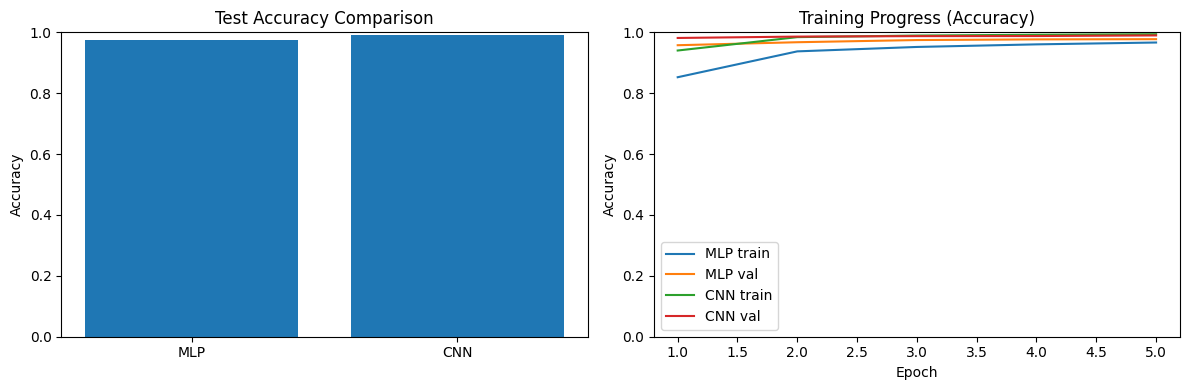

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step
mlp_acc  = mlp_test_acc
cnn_acc  = cnn_test_acc

mlp_hist = mlp_history.history
cnn_hist = cnn_history.history
epochs   = range(1, len(mlp_hist['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Left Bar chart of Test Accuracy
axes[0].bar(['MLP', 'CNN'], [mlp_acc, cnn_acc])  # heights = accuracies
axes[0].set_title('Test Accuracy Comparison')    # Sets Title
axes[0].set_ylabel('Accuracy')                   # Sets Y Label
axes[0].set_ylim(0, 1)                           # y-axis from 0 to 1

# Right line plot for training progress
# Plot training and validation accuracy for both models
axes[1].plot(epochs, mlp_hist['accuracy'], label='MLP train')
axes[1].plot(epochs, mlp_hist['val_accuracy'], label='MLP val')
axes[1].plot(epochs, cnn_hist['accuracy'], label='CNN train')
axes[1].plot(epochs, cnn_hist['val_accuracy'], label='CNN val')
axes[1].set_title('Training Progress (Accuracy)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()                                # Shows legend for the 4 lines

# Adjust layout so subplots and titles do not overlap
plt.tight_layout()
plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

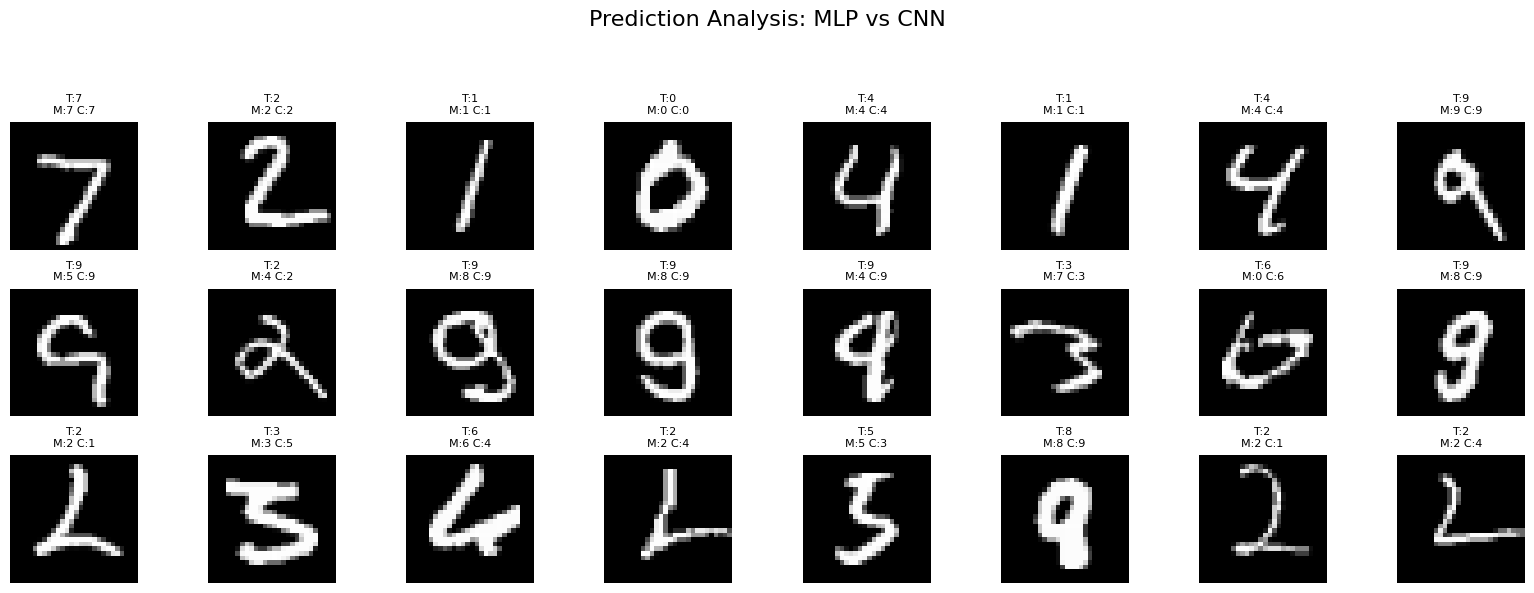

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle("Prediction Analysis: MLP vs CNN", fontsize=16)

# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)

#For CNN correct, MLP wrong
cnn_correct_mlp_wrong = (cnn_predicted_classes == y_test) & (mlp_predicted_classes != y_test)
cnn_correct_mlp_wrong_indices = np.where(cnn_correct_mlp_wrong)[0][:8]

#For MLP correct, CNN wrong
mlp_correct_cnn_wrong = (mlp_predicted_classes == y_test) & (cnn_predicted_classes != y_test)
mlp_correct_cnn_wrong_indices = np.where(mlp_correct_cnn_wrong)[0][:8]

# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)

# Group indices and row labels so we can loop over them
rows_indices = [both_correct_indices, cnn_correct_mlp_wrong_indices, mlp_correct_cnn_wrong_indices]

row_names = ["Both correct", "CNN correct, MLP wrong", "MLP correct, CNN wrong"]

# For each row and each column, show the image and labels
for row, indices in enumerate(rows_indices):
    for col, idx in enumerate(indices):
        ax = axes[row, col]

        # Show the original (or normalized) test image
        ax.imshow(X_test[idx], cmap='gray')
        true_lbl = y_test[idx]
        mlp_lbl  = mlp_predicted_classes[idx]
        cnn_lbl  = cnn_predicted_classes[idx]

        # T = true, M = MLP prediction, C = CNN prediction
        ax.set_title(f"T:{true_lbl}\nM:{mlp_lbl} C:{cnn_lbl}", fontsize=8)
        ax.axis('off')

# Make the layout neat so titles do not overlap
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

1. From our results, the CNN achieved higher test accuracy than the MLP. The MLP reached 97.37% accuracy whie the CNN reached 98.99%. This makes sense because the CNN uses convolution and pooling layers that model local spatial patterns such as edges, strokes, and corners in the images of the digits. Whereas the MLP just looks at each individual pixel. The extra spatial strucutre lets the CNN make more strongers decisions especially with more obscure digits.

2. Both models' training and validation accuracy curves at start very high and rise quickly and then flatten out, but the CNN curve sits conssitently a bit above the MLP's. The gap matches the final test accuracies (98.99% vs 97/37). This shows that both nmodels learn the task well but the CNN starts and reaches a slightly higher and more stable accuracy. For both curves there is no sign of overfitting as both the training and vlaidation cruves stay close together.

3. The accuracy improvement percentage is
((0.9899 - 0.9737) / 0.9737) x 100% = 1.66%.
This tells us how much better the CNN is than the MLP. A 1.66 percentage point gain does not seem like a lot but when dealing with a 10,000 image test set that would correspond to roughly 166 extra images being classified corerctly. That means even though the MLP is doing very well the CNN gives a slight but real improvement.

4. We did not need many epochs because MNIST digits are relatively simple and clean, and our models have more than enough cpacity so they learn the patterns very quickly. With Adam opitmization and good initialization most of the learning happens in the first few passes through the data. So any epochs after 5 would give only tiny improvment past the 97-99% accuracy range. Also after 5 epochs the cruves are almost flat meaning the models are already near their best performance.

5. With more complex images that add things such as colour, backgrounds and have objects in different places/oreientations, the MLP would likely struggle much more because it ignores spatial strucutres and has to memorize many pixel combinations. The CNN would perfrom alot better as it would use convolutional layers and could learn organize and order features. Now the CNN would have to need to be more complex with stronger regularization, data augmentation, and more epochs to reach good performance on a complex dataset. We would also likely see the performance gap increase to be larger than the 1.66% we saw with the MNIST digits.


